In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)


## Load data

In [ ]:
df = pd.read_csv("house_prices.csv")
df.head()


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,2,4.0,3,1975.0,Downtown,Good,Yes,313100
1,4272,3,4.0,2,1968.0,Rural,Fair,Yes,544000
2,3592,1,4.0,3,2009.0,Suburban,Fair,Yes,482200
3,966,1,4.0,2,2020.0,Suburban,Fair,Yes,168500
4,4926,2,4.0,3,1996.0,Suburban,Fair,Yes,649100


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       1000 non-null   int64  
 1   Bedrooms   1000 non-null   int64  
 2   Bathrooms  970 non-null    float64
 3   Floors     1000 non-null   int64  
 4   YearBuilt  970 non-null    float64
 5   Location   1000 non-null   object 
 6   Condition  970 non-null    object 
 7   Garage     1000 non-null   object 
 8   Price      1000 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 70.4+ KB


In [ ]:
df.describe()


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,1000.000000,1000.000000,970.000000,1000.000000,970.000000,1000.000000
mean,2815.422000,2.990000,2.548454,1.964000,1987.640206,417775.400000
std,1255.514921,1.427564,1.133149,0.830297,21.169946,153783.903136
min,503.000000,1.000000,1.000000,1.000000,1950.000000,53800.000000
25%,1749.500000,2.000000,2.000000,1.000000,1969.250000,297200.000000
50%,2862.500000,3.000000,3.000000,2.000000,1988.000000,426550.000000
75%,3849.500000,4.000000,4.000000,3.000000,2006.750000,544025.000000
max,4999.000000,5.000000,4.000000,3.000000,2023.000000,746000.000000


In [ ]:
df.isnull().sum()


,0
Area,0
Bedrooms,0
Bathrooms,30
Floors,0
YearBuilt,30
Location,0
Condition,30
Garage,0
Price,0


## EDA

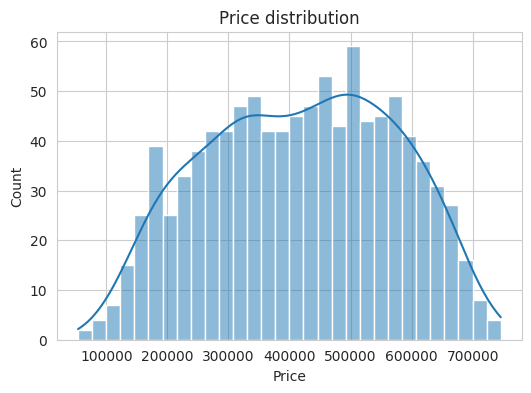

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Price distribution")
plt.show()


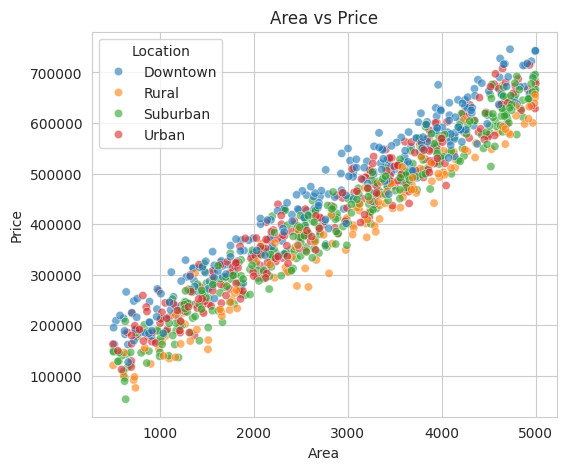

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Area", y="Price", hue="Location", data=df, alpha=0.6)
plt.title("Area vs Price")
plt.show()


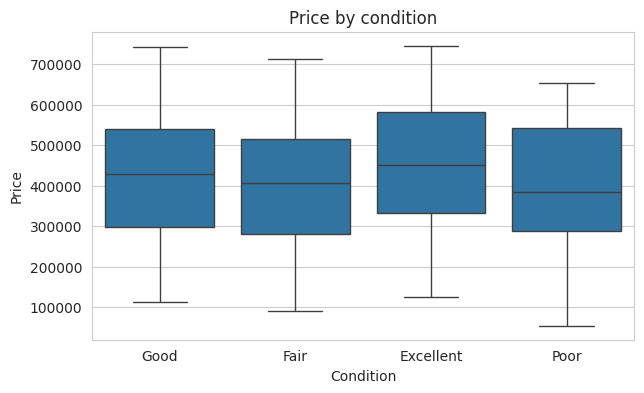

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Condition", y="Price", data=df)
plt.title("Price by condition")
plt.show()


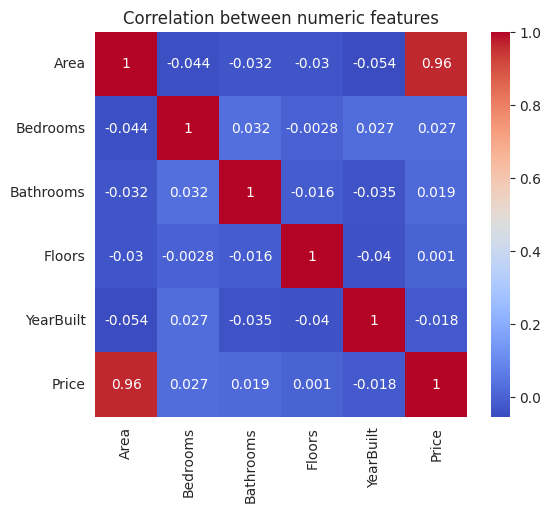

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.show()


Area has the strongest relationship with price, as expected. Location and condition also shift prices noticeably, bedrooms/bathrooms/floors matter but less.

## Preprocessing

In [ ]:
df = df.dropna(subset=["Condition"])
df["Bathrooms"] = df["Bathrooms"].fillna(df["Bathrooms"].median())
df["YearBuilt"] = df["YearBuilt"].fillna(df["YearBuilt"].median())

df["HouseAge"] = 2024 - df["YearBuilt"]
df["Area"] = np.log1p(df["Area"])


In [ ]:
num_features = ["Area", "Bedrooms", "Bathrooms", "Floors", "HouseAge"]
cat_features = ["Location", "Condition", "Garage"]

X = df[num_features + cat_features]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first"), cat_features),
])


## Train models

In [ ]:
linreg = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
linreg.fit(X_train, y_train)
linreg_pred = linreg.predict(X_test)

rf = Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

gb = Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))])
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)


In [ ]:
models = {
    "Linear Regression": (linreg, linreg_pred),
    "Random Forest": (rf, rf_pred),
    "Gradient Boosting": (gb, gb_pred),
}

for name, (model, pred) in models.items():
    rmse = root_mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error").mean()
    print(f"{name}: rmse={rmse:.0f}, mae={mae:.0f}, r2={r2:.3f}, cv_rmse={-cv:.0f}")


Linear Regression: rmse=45712, mae=37061, r2=0.922, cv_rmse=43963


## Residual analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (model, pred)) in zip(axes, models.items()):
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.4)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Predicted price")
    ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()


Residuals are mostly centered around zero with no obvious pattern, so the models aren't systematically over/under-predicting at any price range. Random Forest and Gradient Boosting come out ahead of plain Linear Regression on RMSE, which makes sense given the location/condition premiums aren't perfectly linear.

## Save the best model

In [17]:
best_name = min(models, key=lambda n: root_mean_squared_error(y_test, models[n][1]))
best_model = models[best_name][0]

print("Best model:", best_name)


Best model: Gradient Boosting


In [18]:
joblib.dump(best_model, "house_price_model.joblib")


['house_price_model.joblib']

In [19]:
from google.colab import files
files.download("house_price_model.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference example

In [20]:
def predict_price(area, bedrooms, bathrooms, floors, year_built, location, condition, garage):
    model = joblib.load("house_price_model.joblib")

    x = pd.DataFrame([{
        "Area": np.log1p(area),
        "Bedrooms": bedrooms,
        "Bathrooms": bathrooms,
        "Floors": floors,
        "HouseAge": 2024 - year_built,
        "Location": location,
        "Condition": condition,
        "Garage": garage,
    }])
    return model.predict(x)[0]


predict_price(2200, 3, 2, 2, 2005, "Suburban", "Good", "Yes")


np.float64(355749.9888035288)